## DS2000 & DS2001 Programming with Data & Practicum

# Homework 8: Testing Hypotheses

### 45 Points

## Due Friday, March 21, 10:00PM

**Readings**: 
* [Chap 11 Testing Hypotheses](https://www.inferentialthinking.com/chapters/11/Testing_Hypotheses.html)
* [Chap 12 A/B Testing](https://inferentialthinking.com/chapters/12/1/AB_Testing.html)

Please complete this notebook by filling in the cells provided. Before you begin, execute the following cell to load the provided tests. Each time you start your server, you will need to execute this cell again to load the tests.

For all problems that you must write our explanations and sentences for, you **must** provide your answer in the designated space. Moreover, throughout this homework and all future ones, please be sure to not re-assign variables throughout the notebook! For example, if you use `max_temperature` in your answer to one question, do not reassign it later on.

**Note: This homework has hidden tests on it. That means even though tests may say 100% passed, it doesn't mean your final grade will be 100%. We will be running more tests for correctness once everyone turns in the homework.**


In [1]:
# Run this cell, but please don't change it.

# These lines import the Numpy and Datascience modules.
import numpy as np
from datascience import *

# These lines do some fancy plotting magic
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

import otter
grader = otter.Notebook("hw08.ipynb")

## 1. Soup Dumplings
In late 2018, food writer Chris St. Christie visited 52 soup dumpling restaurants in various neighborhoods of Shanghai, China to quantitatively determine the neighborhood with the best soup dumpling.

At each restaurant, Chris randomly sampled 8 dumplings and measured the following about each dumpling:

* Restaurant : (string) the restaurant’s name
* Soup: (float) the amount of soup, in grams
* Meat : (float) the amount of meat, in grams
* Skin : (float) the thickness of the dumpling skin, in millimeters
* Type : (string) the type of meat used in the dumpling
* Location : (string) the neighborhood where the restaurant is located

They put this data into a dumpling table. Here are the first four rows:

<img src ="DumplingTable.PNG">

Chris also created a Soup Dumpling Index to objectively measure the quality of a soup dumpling. Here is the formula:

$Soup~Dumpling~Index =\frac{Meat~Weight+Soup~Weight}{Skin~Thickness}$

Your friend Ming, a Puxi native, believes that the soup dumplings in Puxi are superior to those of Pudong. She cites that the average Puxi dumpling has a higher soup dumpling index by 2.1 than the average Pudong dumpling.  However, you believe that this difference is just due to chance.

**Question 1.1. (1 pts)** Select the null hypothesis that Ming should use to assess her claims.

1. On average, dumplings made in Puxi have a higher Soup Dumpling Index by 2.1 than dumplings from Pudong.
2. Dumplings made in Puxi have the same Soup Dumpling Index distribution as those made in Pudong.
3. On average, dumplings made in Puxi have a higher Soup Dumpling Index than those made in Pudong, due to chance.
4. On average, dumplings made in Puxi have a higher Soup Dumpling Index than those made in Pudong.
5. Dumplings made in Puxi have a different Soup Dumpling Index distribution  than those made in Pudong.


2

**Question 1.2. (1 pts)** Select the alternative hypothesis that Ming should use to assess her claims.

1. On average, dumplings made in Puxi have a higher Soup Dumpling Index by 2.1 than dumplings from Pudong.
2. Dumplings made in Puxi have the same Soup Dumpling Index distribution as those made in Pudong.
3. On average, dumplings made in Puxi have a higher Soup Dumpling Index than those made in Pudong, due to chance.
4. On average, dumplings made in Puxi have a higher Soup Dumpling Index than those made in Pudong.
5. Dumplings made in Puxi have a different Soup Dumpling Index distribution  than those made in Pudong, due to chance.

4

**Question 1.3. (1 pts)** Select a valid test statistic that Ming could use to assess her claims.

1. Mean Soup Dumpling Index for Puxi dumplings minus mean Soup Dumpling Index for Pudong dumplings.
2.  Mean Soup Dumpling Index for Puxi dumplings minus 2.1.
3.  Absolute difference of mean Soup Dumpling Index for Puxi dumplings minus 2.1.
4.  Absolute  difference of mean Soup Dumpling Index for Puxi dumplings minus mean Soup Dumpling Index for Pudong dumplings.
5.  2.1
6.  Mean Soup Dumpling Index for all dumplings


1

Suppose you learn that online customer reviews seem to be higher for restaurants in Pudong than in Puxi. Ming suspects that this might actually just be due to the fact that the restaurants in Pudong are more likely to adopt the latest experimental trends of adding crab or shrimp to their soup dumplings (Ming, a Pork purist, is not a fan). To test this claim, Ming wants to compare whether Puxi and Pudong have the same distribution of soup dumpling *Type*.


**Question 1.4. (1 pts)**  Select the null hypothesis that Ming should use to assess her claims.

1.  Dumplings made in Puxi have the same Type distribution  as those made in Pudong.
2.  On average, dumplings made in Puxi have a lower Type than those made in Pudong.
3.  On average, dumplings made in Puxi have a higher Type than those made in Pudong.
4.  Dumplings made in Puxi have a different Type distribution  than those made in Pudong.
5.  Dumplings made in Puxi have a different Soup Dumpling Index distribution  than those made in Pudong.


1

**Question 1.5. (1 pts)** Select the alternative hypothesis that Ming should use to assess her claims.

1.  Dumplings made in Puxi have the same Type distribution  as those made in Pudong.
2.  On average, dumplings made in Puxi have a lower Type than those made in Pudong.
3.  On average, dumplings made in Puxi have a higher Type than those made in Pudong.
4.  Dumplings made in Puxi have the a different Type distribution  than those made in Pudong.
5.  Dumplings made in Puxi have a different Soup Dumpling Index distribution  than those made in Pudong.


4

## 2. Using TVD as a Test Statistic

Before beginning this section, please read [this section](https://inferentialthinking.com/chapters/11/2/Multiple_Categories.html#a-new-statistic-the-distance-between-two-distributions) of the textbook on TVD!

Total variation distance (TVD) is a special type of test statistic that we use when we want to compare two distributions of categorical data. It is often used when we observe that a set of observed proportions/probabilities is different than what we expect under the null model. 

Consider a six-sided die that we roll 6,000 times. If the die is fair, we would expect that each face comes up $\frac{1}{6}$ of the time. By random chance, a fair die won't always result in equal proportions (that is, we won't get exactly 1000 of each face). However, if we suspect that the die might be unfair based on the data, we can conduct a hypothesis test using TVD to compare the expected [$\frac{1}{6}$, $\frac{1}{6}$, $\frac{1}{6}$, $\frac{1}{6}$, $\frac{1}{6}$, $\frac{1}{6}$] distribution to what is actually observed.

In this part of the homework, we'll look at how we can use TVD to determine the effect that different factors have on happiness. 

We will be working with data from the [Gallup World Poll](https://www.gallup.com/analytics/349487/gallup-global-happiness-center.aspx#:~:text=World%20Happiness%20Report&text=Using%20the%20Gallup%20World%20Poll,about%20the%20World%20Happiness%20Report.) that is presented in the World Happiness Report, a survey of the state of global happiness. The survey ranked 155 countries by overall happiness and estimated the influence that economic production, social support, life expectancy, freedom, absence of corruption, and generosity had on population happiness. The study has been repeated for several years - we'll be looking at data from the 2016 survey. **Run the cell below to load in the `happiness_scores` table.**

In [2]:
happiness_scores = Table.read_table("happiness_scores.csv")
happiness_scores.show(5)

Country,Region,Happiness Rank,Happiness Score,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity
Denmark,Western Europe,1,7.526,7.46,7.592,1.44178,1.16374,0.79504,0.57941,0.44453,0.36171
Switzerland,Western Europe,2,7.509,7.428,7.59,1.52733,1.14524,0.86303,0.58557,0.41203,0.28083
Iceland,Western Europe,3,7.501,7.333,7.669,1.42666,1.18326,0.86733,0.56624,0.14975,0.47678
Norway,Western Europe,4,7.498,7.421,7.575,1.57744,1.1269,0.79579,0.59609,0.35776,0.37895
Finland,Western Europe,5,7.413,7.351,7.475,1.40598,1.13464,0.81091,0.57104,0.41004,0.25492


Participants in the study were asked to evaluate their life satisfaction from a scale of 0 (worst possible life) to 10 (best possible life). The responses for each country were averaged to create the `Happiness Score`.

The columns `Economy (GDP per Capita)`, `Family`, `Health (Life Expectancy)`, `Freedom`, `Trust (Government Corruption)`, and `Generosity` estimate the extent to which each factor influences happiness, both for better or for worse. The higher the value, the more influential that factor was in calculating the country's happiness score. If you add up all the factors (in addition to a "Difference from Dystopia" value we excluded in the dataset), you get the happiness score.

Let's look at the different factors that affect happiness in the United States. Run the cell below to view the row in `us_happiness` that contains data for the United States.

In [3]:
us_happiness = happiness_scores.where("Country", "United States")
us_happiness

Country,Region,Happiness Rank,Happiness Score,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity
United States,North America,13,7.104,7.02,7.188,1.50796,1.04782,0.779,0.48163,0.14868,0.41077


To compare the different factors, we'll look at the proportion of the happiness score that is attributed to each variable. 
You can find these proportions in the table `us_happiness_factors` after running the cell below.

*Note:* The factors shown in `us_happiness` don't add up exactly to the happiness score, so we adjusted the proportions to  only account for the data we have access to. The proportions were found by dividing each Happiness Factor value by the sum of all Happiness Factor values in `us_happiness`.

In [4]:
us_happiness_factors = Table().read_table("us_happiness_factors.csv")
us_happiness_factors

Happiness Factor,Proportion of Happiness Score
Economy (GDP per Capita),0.344609
Family,0.239455
Health (Life Expectancy),0.178022
Freedom,0.110065
Trust (Government Corruption),0.0339773
Generosity,0.0938718



**Question 2.1. (5 pts)** Suppose we want to test whether or not each factor contributes the same amount (i.e. equally) to the overall Happiness Score. Define the null hypothesis, alternative hypothesis, and test statistic in the cell below. 

*Note:* Please format your answer as follows:
- Null Hypothesis: ...  
- Alternative Hypothesis: ...  
- Test Statistic: ...  


- Null Hyposthesis:  Each factor contributes the same amount to the overall Happiness Score.
- Alternative Hypothesis:  Each factor does not contribute the same amount to the overall Happiness Score.
- Test Statistic:  TVD of the simulated distribution and null hypothesis distribution.

**Question 2.2. (4 pts)** Write a function `calculate_tvd` that takes in the observed distribution (`obs_dist`) and expected distribution under the null hypothesis (`null_dist`) and calculates the total variation distance. Use this function to set `observed_tvd` to be equal to the observed test statistic. 

In [5]:
null_distribution = np.ones(6) * (1/6)

observed_distribution = us_happiness_factors.column(
    "Proportion of Happiness Score")

def calculate_tvd(obs_dist, null_dist):
    return sum(abs(null_dist - obs_dist))/2
    
observed_tvd = calculate_tvd(observed_distribution, null_distribution)
observed_tvd

0.26208562431156396

In [6]:
grader.check("q2_2")

q2_2 results: All test cases passed!

**Question 2.3. (3 pts)** Create an array called `simulated_tvds` that contains 10,000 simulated values under the null hypothesis. Assume that the original sample consisted of 1,000 individuals.

*Hint:* The `sample_proportions` function may be helpful to you. Refer to the [Python Reference sheet](http://data8.org/fa21/python-reference.html#:~:text=sample_proportions(sample_size%2C%20model_proportions)) to read up on it!

In [7]:
simulated_tvds = make_array()
num_simulations = 10000

for i in np.arange(num_simulations):
    simulated_tvds = np.append(simulated_tvds, calculate_tvd(
        sample_proportions(1000, null_distribution), null_distribution))

In [8]:
grader.check("q2_3")

q2_3 results: All test cases passed!

Run the cell below to plot a histogram of your simulated test statistics, as well as the observed value of the test statistic.

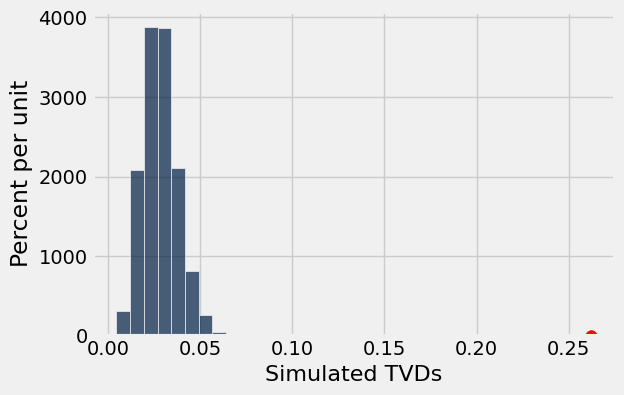

In [9]:
Table().with_column("Simulated TVDs", simulated_tvds).hist()
plt.scatter(observed_tvd, 0, color='red', s=70, zorder=2);
plt.show();

**Question 2.4. (2 pts)** Use your simulated statistics to calculate the p-value of your test. Make sure that this number is consistent with what you observed in the histogram above. 

In [10]:
p_value_tvd = np.count_nonzero(simulated_tvds >= observed_tvd)/num_simulations
p_value_tvd

0.0

In [11]:
grader.check("q2_4")

q2_4 results: All test cases passed!

**Question 2.5. (3 pts)** What can you conclude about how each factor contributes to the overall happiness score in the US? Explain your answer using the results of your hypothesis test. Assume a p-value cutoff of 5%. 

It can be concluded that each factor does not contribute equally to the overall happiness score in the US, making the alternative hypothesis true. The alternative is true because the p-value is approximately 0, which is extremely statistically significant.

## 3. Who is Older?

Data scientists have drawn a simple random sample of size 500 from a large population of adults. Each member of the population happened to identify as either "male" or "female". Data was collected on several attributes of the sampled people, including age. The table `sampled_ages` contains one row for each person in the sample, with columns containing the individual's gender identity.

In [12]:
sampled_ages = Table.read_table('age.csv')
sampled_ages.show(5)

Gender,Age
male,23
male,29
male,29
female,49
female,33


**Question 3.1. (2 pts)** How many females were there in our sample? Keep in mind that `group` sorts categories in alphabetical order. 

In [13]:
num_females = sampled_ages.group("Gender").column("count").item(0)
num_females

260

In [14]:
grader.check("q3_1")

q3_1 results: All test cases passed!

**Question 3.2. (3 pts)** Complete the cell below so that `avg_male_vs_female` evaluates to `True` if the sampled males are older than the sampled females on average, and `False` otherwise. Use Python code to achieve this.

In [15]:
group_mean_tbl = sampled_ages.group("Gender", np.average)
group_means = group_mean_tbl.column("Age average")       # array of mean ages
avg_male_vs_female = group_means.item(1) > group_means.item(0)
avg_male_vs_female

True

In [16]:
grader.check("q3_2")

q3_2 results: All test cases passed!

**Question 3.3. (2 pts)** The data scientists want to use the data to test whether males are older than females or, in other words, whether the ages of the two groups have the same distribution. One of the following statements is their null hypothesis and another is their alternative hypothesis. Assign `null_statement_number` and `alternative_statement_number` to the numbers of the correct statements in the code cell below. 

1. In the sample, the males and females have the same distribution of ages; the sample averages of the two groups are different due to chance.
2. In the population, the males and females have the same distribution of ages; the sample averages of the two groups are different due to chance.
3. The age distributions of males and females in the population are different due to chance.
4. The males in the sample are older than the females, on average.
5. The males in the population are older than the females, on average.
6. The average ages of the males and females in the population are different.

In [17]:
null_statement_number = 2
alternative_statement_number = 6

In [18]:
grader.check("q3_3")

q3_3 results: All test cases passed!

**Question 3.4. (1 pts)** The data scientists have decided to use a permutation test. Assign `permutation_test_reason` to the number corresponding to the reason they made this choice. 

1. Since a person's age can't be related to their gender under the null hypothesis, it doesn't matter who is labeled "male" and who is labeled "female", so you can use permutations.
2. Under the null hypothesis, permuting the labels in the `sampled_ages` table is equivalent to drawing a new random sample with the same number of males and females as in the original sample.
3. Under the null hypothesis, permuting the rows of `sampled_ages` table is equivalent to drawing a new random sample with the same number of males and females as in the original sample.

In [19]:
permutation_test_reason = 1
permutation_test_reason

1

In [20]:
grader.check("q3_4")

q3_4 results: All test cases passed!

**Question 3.5. (1 pts)** To test their hypotheses, the data scientists have followed our textbook's advice and chosen a test statistic where the following statement is true: Large values of the test statistic favor the alternative hypothesis.

The data scientists' test statistic is one of the two options below. Which one is it? Assign the appropriate number to the variable `correct_test_stat`. 

1. "male age average - female age average" in a sample created by randomly shuffling the male/female labels
2. "|male age average - female age average|" in a sample created by randomly shuffling the male/female labels

In [21]:
correct_test_stat = 2
correct_test_stat

2

In [22]:
grader.check("q3_5")

q3_5 results: All test cases passed!

**Question 3.6. (2 pts)** Complete the cell below so that `observed_statistic_ab` evaluates to the observed value of the data scientists' test statistic. Use as many lines of code as you need, and remember that you can use any quantity, table, or array that you created earlier. 

In [23]:
observed_statistic_ab = abs(group_means.item(1) - group_means.item(0))
observed_statistic_ab

1.314102564102562

In [24]:
grader.check("q3_6")

q3_6 results: All test cases passed!

**Question 3.7. (2 pts)** Assign `shuffled_labels` to an array of shuffled male/female labels. The rest of the code puts the array in a table along with the data in `sampled_ages`. 

In [25]:
shuffled_labels = sampled_ages.sample(with_replacement=False
                                     ).column("Gender")

original_with_shuffled_labels = sampled_ages.with_columns(
    'Shuffled Label', shuffled_labels)
original_with_shuffled_labels

Gender,Age,Shuffled Label
male,23,female
male,29,male
male,29,male
female,49,female
female,33,female
male,31,male
male,60,female
male,38,female
female,60,female
female,27,female


In [26]:
grader.check("q3_7")

q3_7 results: All test cases passed!

**Question 3.8. (1 pts)** [Pretend this is a midterm problem and solve it without doing the calculation in a code cell.] The comparison below uses the array `shuffled_labels` from Question 3.7 and the count `num_females` from Question 3.1. 

For this comparison, assign the correct number from one of the following options to the variable `correct_q3_q8`.

`comp = np.count_nonzero(shuffled_labels == 'female') == num_females`

1. `comp` is set to `True`.
2. `comp` is set to `False`.
3. `comp` is set to `True`, or `False`, depending on how the shuffle came out.

In [27]:
correct_q3_8 = 1
correct_q3_8

1

In [28]:
grader.check("q3_8")

q3_8 results: All test cases passed!

**Question 3.9. (4 pts)** Define a function `simulate_one_statistic` that takes on arguments and returns one simulated value of the test statistic. We've given you a skeleton, but feel free to approach this question in a way that makes sense to you. Use as many lines of code as you need. Refer to the code you have previously written in this problem, as you might be able to re-use some of it. 

In [29]:
def simulate_one_statistic():
    "Returns one value of our simulated test statistic"
    shuffled_labels = sampled_ages.sample(with_replacement=False
                                         ).column("Gender")
    shuffled_tbl = sampled_ages.with_columns(
        'Shuffled Label', shuffled_labels).drop("Gender")
    group_means = shuffled_tbl.group("Shuffled Label", np.average
                                    ).column("Age average")
    return abs(group_means.item(1) - group_means.item(0))

In [30]:
grader.check("q3_9")

q3_9 results: All test cases passed!

After you have defined your function, run the following cell a few times to see how the statistic varies.

In [35]:
simulate_one_statistic()

0.5128205128205181

**Question 3.10. (2 pts)** Complete the cell to simulate 4,000 values of the statistic. We have included the code that draws the empirical distribution of the statistic and shows the value of `observed_statistic_ab` from Question 3.6.

*Note:* This cell will take around a minute to run.

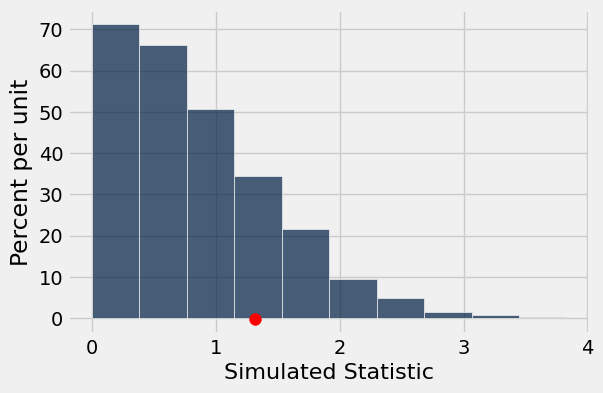

In [36]:
# this cell will take some time to run
repetitions = 4000
simulated_statistics_ab = make_array()

for i in np.arange(4000):
    simulated_statistics_ab = np.append(
        simulated_statistics_ab, simulate_one_statistic())


Table().with_columns('Simulated Statistic', simulated_statistics_ab).hist()
plt.scatter(observed_statistic_ab, -0.002, color='red', s=70);

In [37]:
grader.check("q3_10")

q3_10 results: All test cases passed!

**Question 3.11. (3 pts)** Use the simulation to find an empirical approximation to the p-value. Assign `p_val` to the appropriate p-value from this simulation. Then, assign `conclusion` to either `null_hyp` or `alt_hyp`.

*Note:* Assume that we use the 5% cutoff for the p-value.

In [38]:
# These are variables provided for you to use.
null_hyp = 'The data are consistent with the null hypothesis.'
alt_hyp = 'The data support the alternative more than the null.'

p_val = np.count_nonzero(
    simulated_statistics_ab >= observed_statistic_ab)/repetitions
conclusion = null_hyp

p_val, conclusion # Do not change this line

(0.214, 'The data are consistent with the null hypothesis.')

In [39]:
grader.check("q3_11")

q3_11 results: All test cases passed!

---

To double-check your work, the cell below will rerun all of the autograder tests.

In [40]:
grader.check_all()

q2_2 results: All test cases passed!

q2_3 results: All test cases passed!

q2_4 results: All test cases passed!

q3_1 results: All test cases passed!

q3_10 results: All test cases passed!

q3_11 results: All test cases passed!

q3_2 results: All test cases passed!

q3_3 results: All test cases passed!

q3_4 results: All test cases passed!

q3_5 results: All test cases passed!

q3_6 results: All test cases passed!

q3_7 results: All test cases passed!

q3_8 results: All test cases passed!

q3_9 results: All test cases passed!

**You've completed Homework 8!**

Please save your notebook, download a pdf version of the notebook, and submit it to Gradescope.